# 05 - REPRESENTATIONS TF-IDF ET SIMILARITES

Module 2 : *Apprendre à comparer*. Pour chaque livre, on construit un vecteur TF-IDF, qu'on utilise pour mesurer la similarité entre l'extrait d'un livre inconnu et chaque livre du corpus.

Conformément au sujet, le TF-IDF est implémenté à la main (`pipeline.representations.TfIdfMaison`). On le valide en vérifiant qu'il reproduit exactement `sklearn.TfidfVectorizer` sur un corpus jouet.


## Setup

In [1]:
import sys
from pathlib import Path

# Se déplacer dans le dossier du projet (NE LANCER Q'UNE FOIS)
%cd ../
%ls

/data/projets/EVAL_MASTER1/projet_nlp_app
'BC02 - Projet - 2.pdf'     audit_corpus.png*          notebooks/
 Dockerfile                 audit_corpus.py            pg_catalog.csv*
 README.md*                 build_serving_bundle.py*   pipeline/
 __pycache__/               conftest.py                requirements-dev.txt*
 api.py                     diagnostic_mmr.png*        requirements.txt
 app/                       diagnostic_mmr.py          resultats/
 audit_clean_border.py      docs/                      scripts/
 audit_clean_borders.txt*   figures/                   start.sh
 audit_corpus.csv*          models/                    tests/


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline.config import BENCH_PARAMS, TFIDF_PARAMS
from pipeline.corpus import charger_corpus, trouver_livre
from pipeline.representations import (
    TfIdfMaison,
    similarites_cosinus,
    similarites_euclidiennes
)

CFG = {
    "figures_dir":         Path("figures"),
    "min_df":              TFIDF_PARAMS["min_df"],
    "max_df_ratio":        TFIDF_PARAMS["max_df_ratio"],
    "n_extraits_par_livre": BENCH_PARAMS["n_extraits_par_livre"],
    # Longueur de l'extrait de DEMONSTRATION plus bas, pas du benchmark.
    # Le benchmark, lui, prend la plage de BENCH_PARAMS via
    # `tirer_extraits`, donc les memes reglages que scripts/run_benchmark.
    "taille_extrait":      200,
    "seed":                BENCH_PARAMS["seed"],
}
CFG["figures_dir"].mkdir(exist_ok=True)
rng = np.random.default_rng(CFG["seed"])

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

## Chargement des annotations

In [3]:
# with_df=False : ce notebook ne lit que les sequences `lemmes` et
# `tokens`, jamais les DataFrames annotes. Les retenir couterait ~2,2 Go
# de RSS sur le corpus actuel pour des objets inutilises ici.
corpus = charger_corpus(with_df=False)

Chargement de 291 livres annotes...


    10/291 livres  (123.7s ecoulees,  0.1/s, ~3477s restantes)


    20/291 livres  (123.7s ecoulees,  0.2/s, ~1677s restantes)


  override genre: pg17989_le_comte_de_monte_cristo_tome_i historical_fiction -> adventure


    30/291 livres  (183.6s ecoulees,  0.2/s, ~1598s restantes)


...

   270/291 livres  (327.3s ecoulees,  0.0/s, temps restant inconnu)


   280/291 livres  (327.3s ecoulees,  0.0/s, temps restant inconnu)


   290/291 livres  (327.3s ecoulees,  0.0/s, temps restant inconnu)


   291/291 livres  (327.3s ecoulees,  0.0/s, temps restant inconnu)


  1 override(s) de genre appliques.
  291 livres charges en 327.3s (8 telechargements simultanes)


## Validation contre sklearn

Vérification que `TfIdfMaison` produit exactement la même matrice que `sklearn.TfidfVectorizer` sur un petit corpus jouet. Si l'`assert` passe, on à la garantie que les calculs sur le vrai corpus seront corrects.


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

docs_test = [
    "le chat mange une souris".split(),
    "le chien mange un os".split(),
    "la souris court vite".split(),
]

vec_maison = TfIdfMaison(ngram_max=1, min_df=1, max_df_ratio=1.0)
# `.toarray()` : TfIdfMaison renvoie une csr_matrix depuis le passage a
# l'echelle du corpus. Densifier est sans consequence ici, le corpus jouet
# faisant trois documents, et c'est necessaire pour comparer terme a terme
# avec la sortie de sklearn.
X_maison = vec_maison.fit_transform(docs_test).toarray()

vec_sk = TfidfVectorizer(analyzer=lambda x: x, norm="l2", smooth_idf=True)
X_sk = vec_sk.fit_transform(docs_test).toarray()

vocab_sk = list(vec_sk.get_feature_names_out())
ordre_maison = [vec_maison.index_[t] for t in vocab_sk]
X_maison_aligne = X_maison[:, ordre_maison]

egal = np.allclose(X_maison_aligne, X_sk, atol=1e-10)
diff_max = np.abs(X_maison_aligne - X_sk).max()
print(f"Vocabulaire identique : {sorted(vec_maison.vocabulaire_) == sorted(vocab_sk)}")
print(f"Matrices identiques   : {egal} (diff max = {diff_max:.2e})")
assert egal
print("\nValidation OK : on peut utiliser TfIdfMaison en confiance.")

Vocabulaire identique : True
Matrices identiques   : True (diff max = 0.00e+00)

Validation OK : on peut utiliser TfIdfMaison en confiance.


## Construction des trois matrices TF-IDF du corpus

Trois configurations pour comparer l'effet du choix de tokens et de la taille des n-grammes :

- `lemmes_1g` : lemmes seulement, unigrammes
- `lemmes_12g` : lemmes, uni + bigrammes
- `tokens_12g` : formes flechies, uni + bigrammes


In [5]:
configs = {
    "lemmes_1g":  {"champ": "lemmes", "ngram_max": 1},
    "lemmes_12g": {"champ": "lemmes", "ngram_max": 2},
    "tokens_12g": {"champ": "tokens", "ngram_max": 2},
}

matrices = {}
vectoriseurs = {}

for nom, cfg in configs.items():
    documents = [c[cfg["champ"]] for c in corpus]
    vec = TfIdfMaison(
        ngram_max=cfg["ngram_max"],
        min_df=CFG["min_df"],
        max_df_ratio=CFG["max_df_ratio"],
    )
    X = vec.fit_transform(documents)
    matrices[nom] = X
    vectoriseurs[nom] = vec
    print(f"{nom:12s} : matrice {X.shape}, vocabulaire {len(vec.vocabulaire_):,} termes")


lemmes_1g    : matrice (291, 143882), vocabulaire 143,882 termes


lemmes_12g   : matrice (291, 4144734), vocabulaire 4,144,734 termes


tokens_12g   : matrice (291, 5048963), vocabulaire 5,048,963 termes


## Deux métriques de similarité

- **Cosinus.** Sur des vecteurs L2-normalisés, le cosinus se réduit au produit scalaire `u·v`. Référence en recherche d'information.
- **Distance euclidienne.** Sur des vecteurs L2-normalisés, `d² = 2 - 2 cos`, donc euclidien et cosinus donnent **le même classement**. On l'inclut quand même, converti en proximité par `1 / (1 + d)`, pour le vérifier sur les chiffres plutôt que de l'affirmer.

Jaccard, mentionné dans les versions précédentes de ce notebook, n'y est pas calculé : il l'est dans `scripts/run_benchmark.py`, qui l'évalue sur les trois configurations. Il perd nettement, ce qui est attendu puisqu'il ignore à la fois les fréquences et les poids IDF.

## Démonstration sur un extrait unique

On prend 200 mots aléatoires d'un livre, on calcule les trois similarités, et on regarde le classement.


In [6]:
livre_demo = trouver_livre(corpus, 0)  # premier livre du corpus
print(f"Extrait pris dans : {livre_demo['auteur']} -- {livre_demo['livre']}")

lemmes = livre_demo["lemmes"]
debut = rng.integers(0, len(lemmes) - CFG["taille_extrait"])
extrait_lemmes = lemmes[debut: debut + CFG["taille_extrait"]]
print(f"Position : token {debut} a {debut + CFG['taille_extrait']}")
print(f"Premiers lemmes : {' '.join(extrait_lemmes[:20])}...\n")

vec = vectoriseurs["lemmes_1g"]
X = matrices["lemmes_1g"]
requete = vec.transform([extrait_lemmes])[0]

sims_cos = similarites_cosinus(X, requete)
sims_euc = similarites_euclidiennes(X, requete)
ensembles = [set(c["lemmes"]) for c in corpus]

df_demo = pd.DataFrame({
    "livre":     [c["auteur"] for c in corpus],
    "cosinus":   sims_cos,
    "euclidien": sims_euc
}).sort_values("cosinus", ascending=False).reset_index(drop=True)
df_demo.head(10)

Extrait pris dans : Amundsen Roald -- En Avion Vers Le Pole Nord
Position : token 1934 a 2134
Premiers lemmes : recueillir mets plaisir disposition radio expédié septembre maud captif banquise dr sverdrup expliquer observation marée effectuer campagne océan glacial sibérie...



,livre,cosinus,euclidien
0,Amundsen Roald,0.548313,0.512700
1,Bougainville Louis Antoine De Comte,0.090918,0.425823
2,Ruskin John,0.054211,0.420991
3,Graffigny H De Henry,0.053938,0.420956
4,Chancel A De Ausone,0.047158,0.420086
5,Aynard Theodore,0.042088,0.419440
6,Verne Jules,0.039879,0.419159
7,Corbiere Edouard,0.039800,0.419149
8,Fournier Edouard,0.039695,0.419136
9,Various,0.039400,0.419099


## Benchmark systématique

Pour chaque livre, on génère `n_extraits_par_livre` extraits aléatoires de `taille_extrait` mots, et pour chaque extrait on calcule les 3 similarités sur les 3 configurations (9 combinaisons par extrait). On enregistre le rang du vrai livre dans chaque classement -- idéal = 1.


In [7]:
# Le tirage passe par `pipeline.benchmark.tirer_extraits`, et ce n'est pas
# cosmetique.
#
# La version precedente tirait `debut_l` et `debut_t` INDEPENDAMMENT : les
# extraits « lemmes » et « tokens » d'une meme ligne ne portaient donc pas
# sur le meme passage du livre. Comparer les representations sur cette base
# revenait a comparer des reponses a des questions differentes, et l'ecart
# mesure melangeait l'effet de la representation a celui du hasard du
# tirage. `tirer_extraits` decoupe les deux champs au MEME endroit.
#
# La longueur devient aussi une plage (7-70 termes informatifs) au lieu des
# 200 fixes d'origine. 200 termes valent ~573 mots colles, presque le double
# du maximum que propose l'app : l'ancien protocole mesurait un regime que
# le produit ne peut pas produire.
#
# Consequence a assumer : les chiffres de ce notebook changent, et ils sont
# desormais comparables a ceux de `scripts/run_benchmark.py`, ce qui etait
# precisement le probleme avant.
from pipeline.benchmark import tirer_extraits

extraits_bench = tirer_extraits(
    corpus,
    n_par_livre=CFG["n_extraits_par_livre"],
    taille=BENCH_PARAMS["taille_extrait"],
    seed=CFG["seed"],
)

# On reconstruit l'index du livre source, que la suite du notebook attend.
index_par_slug = {c["livre_slug"]: i for i, c in enumerate(corpus)}
extraits = [
    {
        "livre_idx": index_par_slug[e["livre_slug"]],
        "source":    e["auteur"],
        "lemmes":    e["lemmes"],
        "tokens":    e["tokens"],
    }
    for e in extraits_bench
]

tailles = [len(e["lemmes"]) for e in extraits]
print(f"{len(extraits)} extraits generes ({CFG['n_extraits_par_livre']} par livre)")
print(f"longueur : de {min(tailles)} a {max(tailles)} termes informatifs, "
      f"mediane {int(np.median(tailles))}")

1455 extraits generes (5 par livre)
longueur : de 7 a 70 termes informatifs, mediane 40


In [8]:
ensembles_lemmes = [set(c["lemmes"]) for c in corpus]
ensembles_tokens = [set(c["tokens"]) for c in corpus]

lignes = []
for ext in extraits:
    cible = ext["livre_idx"]
    for nom_config, cfg in configs.items():
        vec = vectoriseurs[nom_config]
        X = matrices[nom_config]
        champ = cfg["champ"]
        requete_termes = ext[champ]
        requete_vec = vec.transform([requete_termes])[0]

        ensembles = ensembles_lemmes if champ == "lemmes" else ensembles_tokens
        requete_set = set(requete_termes)

        for nom_metrique, sims in [
            ("cosinus",   similarites_cosinus(X, requete_vec)),
            ("euclidien", similarites_euclidiennes(X, requete_vec))
        ]:
            ordre = np.argsort(-sims)
            rang = int(np.where(ordre == cible)[0][0]) + 1
            lignes.append({
                "config":      nom_config,
                "metrique":    nom_metrique,
                "livre_cible": ext["source"],
                "rang":        rang,
                "score_top1":  sims[ordre[0]],
                "score_cible": sims[cible],
            })

resultats = pd.DataFrame(lignes)
print(f"{len(resultats):,} evaluations effectuees")


8,730 evaluations effectuees


## Récapitulatif des performances

In [9]:
def stats_par_combinaison(df):
    return pd.Series({
        "top_1":       (df["rang"] == 1).mean() * 100,
        "top_3":       (df["rang"] <= 3).mean() * 100,
        "top_5":       (df["rang"] <= 5).mean() * 100,
        "MRR":         (1 / df["rang"]).mean(),
        "rang_median": df["rang"].median(),
    })

tableau = (
    resultats
    .groupby(["config", "metrique"])
    .apply(stats_par_combinaison, include_groups=False)
    .round(2)
    .sort_values("top_1", ascending=False)
)
tableau

top_1  top_3  top_5   MRR  rang_median
config     metrique                                         
tokens_12g cosinus    93.95  99.24  99.73  0.97          1.0
           euclidien  93.95  99.24  99.73  0.97          1.0
lemmes_12g euclidien  92.65  98.97  99.59  0.96          1.0
           cosinus    92.65  98.97  99.59  0.96          1.0
lemmes_1g  euclidien  70.31  84.26  88.52  0.78          1.0
           cosinus    70.31  84.26  88.52  0.78          1.0

## Visualisation des résultats

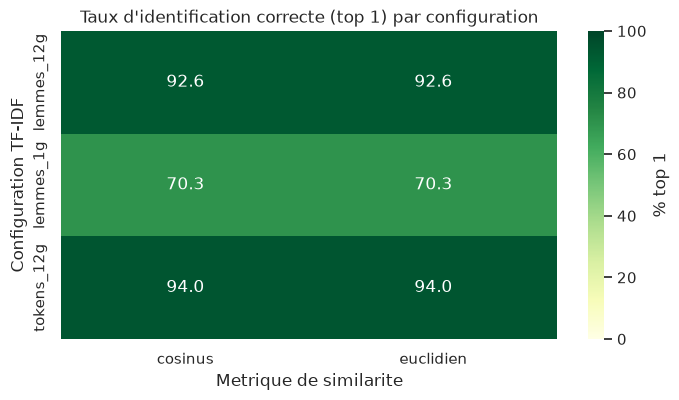

In [10]:
pivot_top1 = (
    resultats
    .assign(top1=resultats["rang"] == 1)
    .groupby(["config", "metrique"])["top1"]
    .mean()
    .mul(100)
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot_top1, annot=True, fmt=".1f", cmap="YlGn",
            cbar_kws={"label": "% top 1"}, vmin=0, vmax=100, ax=ax)
ax.set_title("Taux d'identification correcte (top 1) par configuration")
ax.set_xlabel("Metrique de similarite")
ax.set_ylabel("Configuration TF-IDF")
plt.savefig(CFG["figures_dir"] / "benchmark_top1.png")
plt.show()

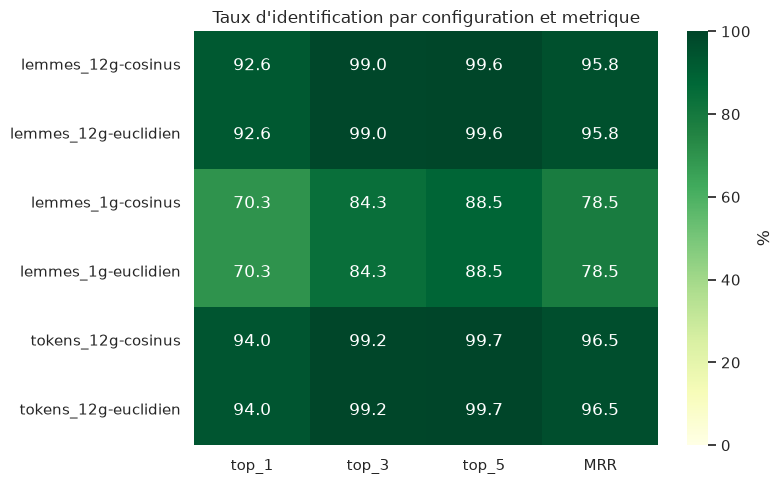

In [11]:
import seaborn as sns

stats = (
    resultats
    .groupby(["config", "metrique"])
    .apply(lambda d: pd.Series({
        "top_1":  (d["rang"] == 1).mean() * 100,
        "top_3":  (d["rang"] <= 3).mean() * 100,
        "top_5":  (d["rang"] <= 5).mean() * 100,
        "MRR":    (1 / d["rang"]).mean() * 100,
    }), include_groups=False)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(stats, annot=True, fmt=".1f", cmap="YlGn",
            vmin=0, vmax=100, cbar_kws={"label": "%"}, ax=ax)
ax.set_title("Taux d'identification par configuration et metrique")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Analyse des échecs

Quels livres sont les plus difficiles à identifier ? Sur la meilleure configuration, on regarde les extraits ou le rang du vrai livre est > 1.


In [12]:
config_best, metrique_best = tableau.index[0]
meilleure = tableau.iloc[0]
print(f"Meilleure combinaison : {config_best} + {metrique_best} ({meilleure['top_1']:.1f}% top 1)\n")

echecs = resultats[
    (resultats["config"] == config_best)
    & (resultats["metrique"] == metrique_best)
    & (resultats["rang"] > 1)
]
if len(echecs) == 0:
    print("Aucune erreur sur la meilleure configuration.")
else:
    print(f"{len(echecs)} extraits mal classes :")
    print(
        echecs.groupby("livre_cible")
        .agg(n_echecs=("rang", "size"),
             rang_moyen=("rang", "mean"),
             rang_max=("rang", "max"))
        .sort_values("n_echecs", ascending=False)
    )


Meilleure combinaison : tokens_12g + cosinus (94.0% top 1)

88 extraits mal classes :
                            n_echecs  rang_moyen  rang_max
livre_cible                                               
Segur Sophie Comtesse De           6    2.000000         2
Vidocq Eugene Francois             4    2.500000         3
Aragon                             4    2.000000         2
Fouche Joseph Duc Dotrante         3    2.333333         3
Hugo Victor                        3    2.000000         2
...                              ...         ...       ...
Rouquette Louis Frederic           1    2.000000         2
Shakespeare William                1    2.000000         2
Silvestre Armand                   1    2.000000         2
Weyman Stanley John                1    2.000000         2
Zola Emile                         1    2.000000         2

[61 rows x 3 columns]


## Conclusions

**1. Cosinus et euclidien donnent le même classement, toujours.** Sur des vecteurs L2-normalisés, `||u-v||² = 2 - 2 u·v` : la distance est une fonction strictement décroissante du cosinus. Le tableau le confirme, les deux lignes de chaque configuration sont identiques jusqu'à la décimale. Ce n'est pas une confirmation croisée, c'est la même mesure écrite deux fois.

**2. Les bigrammes ne sont pas un gain marginal, ils sont décisifs.** `lemmes_12g` fait 92,65 % contre 70,31 % pour `lemmes_1g`, soit **22,3 points**. La version précédente de ce notebook concluait à un « gain marginal » : c'était vrai sur 26 livres, où l'écart valait 1,2 point, et c'est faux ici. La raison est mécanique : un unigramme discriminant dans un corpus de 26 livres ne l'est plus dans 291, alors qu'un bigramme reste presque unique quelle que soit la taille du corpus.

Le test apparié de `scripts/tests_apparies.py` donne McNemar `p = 2,8 × 10⁻⁹³` sur 331 paires discordantes réparties 328 contre 3.

**3. Les tokens battent les lemmes.** `tokens_12g` fait 93,95 % contre 92,65 %, soit 1,31 point, confirmé par McNemar (`p = 8,8 × 10⁻⁴`, 25 extraits contre 6). C'est ce qui a fait basculer le bundle servi. La lemmatisation normalise les formes fléchies, ce qui aide à regrouper deux occurrences d'un même mot mais efface des indices : sur une tâche d'**identification**, la forme exacte employée par l'auteur est elle-même une signature.

**4. Le prix se paie en vocabulaire.** 143 882 termes pour `lemmes_1g`, 4,1 M pour `lemmes_12g`, 5,0 M pour `tokens_12g`. En matrice dense, la configuration servie demanderait 291 × 5 048 963 × 8 octets, soit **11,8 Go** : ce notebook n'aurait pas pu tourner. C'est le passage de `TfIdfMaison` en `csr_matrix` qui le rend possible.

**5. Les erreurs restantes sont des voisins immédiats.** Sur les 88 extraits mal classés, le rang du vrai livre est presque toujours 2. Ce ne sont pas des échecs d'identification mais des départages entre œuvres proches : deux tomes du même roman, deux recueils du même auteur.

### À lire avec ces chiffres

Les extraits sont tirés des livres eux-mêmes indexés, donc l'extrait est littéralement contenu dans le document cible. Les scores sont mécaniquement hauts et ne se transposent pas à un extrait d'un livre absent du corpus. C'est l'usage réel de l'app, mais il faut le dire.